# Determinants and Predictive Modeling of H1N1 and Seasonal Influenza Vaccination Uptake

## Introduction 

Influenza A (H1N1) is a highly contagious respiratory virus capable of causing illness ranging from mild infection to severe disease, with the potential to trigger global outbreaks due to frequent genetic mutations. Despite the availability of effective vaccines, vaccination uptake remains inconsistent across populations. Understanding the factors that influence vaccination behavior is therefore essential for improving public health outcomes and strengthening immunization strategies for both H1N1 and seasonal influenza.

This study analyzes vaccination uptake patterns using demographic, behavioral, and perceptual variables. It specifically examines how education, preventive health behaviors, and health-related perceptions influence individuals’ decisions to receive H1N1 and seasonal flu vaccines. Of particular interest are perceived disease risk and perceived vaccine effectiveness, which reflect key components of health belief theory and are expected to shape vaccination behavior significantly.

By integrating these factors, the study aims to identify the key drivers of vaccination uptake and provide a comprehensive understanding of the behavioral and cognitive determinants of vaccine acceptance. The findings are intended to support the design of more effective public health interventions and targeted vaccination campaigns.

## 2. Business Understanding

### Business context 

Influenza A (H1N1), as identified by the World Health Organization, is a highly transmissible virus responsible for major outbreaks, including the 2009 pandemic. Its ability to mutate rapidly and spread widely makes it a persistent public health threat with significant economic consequences, including increased healthcare costs and productivity losses. Vaccination remains the most effective and cost-efficient intervention for reducing the disease burden.

Despite the availability of vaccines, uptake varies considerably across populations, limiting the overall effectiveness of immunization programs. This study adopts a data-driven approach to examine factors influencing vaccination behavior for both H1N1 and seasonal influenza, with a particular focus on education level, behavioral patterns, and health perceptions such as perceived risk and vaccine effectiveness. The findings are intended to guide policymakers and healthcare stakeholders in improving vaccine uptake through better targeting, strengthened public trust, and more efficient allocation of healthcare resources.

### Business Objectives 

To identify  factors influence vaccination uptake for H1N1 and seasonal influenza

Specific Objectives

        1. To analyze the distribution of H1N1 and seasonal influenza vaccination uptake

        2. To assess the relationship between education factors and vaccination uptake.

        3. To assess the effect of perceived vaccine effectiveness on vaccination uptake
        
        4. To establish effect of perceived disease risk and vaccine effectiveness on H1N1 and seasonal influenza vaccination uptake

### Business Question 

How does distribution of H1N1 and seasonal influenza vaccination uptake?

How are the relationship between education factors and vaccination uptake?

What are the effect of perceived H1N1 and seasonal influenza risk on vaccination uptake?

How are the effect of perceived disease risk and vaccine effectiveness on H1N1 and seasonal influenza vaccination uptake?

### Stakeholders

Stakeholders are individuals or organizations that use, influence, or are affected by the public health and healthcare system. In the context of influenza vaccination analysis, key stakeholders include:

Public Health Authorities
Healthcare Providers
Program Managers
Insurance Providers
Community Health Workers
General Public
High-Risk Groups
Policy Makers
Non-Governmental Organizations (NGOs) and International Health Organizations
Data Science and Analytics Teams

Each stakeholder benefits from the insights and outputs of this analysis in different ways:

Policy Makers & Public Health Authorities: Use insights to develop evidence-based policies, plan vaccination campaigns, and allocate vaccine supplies efficiently.
Program Managers: Design and optimize immunization programs and resource distribution strategies.
Healthcare Providers: Recommend vaccinations to patients based on risk factors and improve clinical decision-making.
Community Health Workers & NGOs: Conduct targeted outreach and community engagement to improve awareness and vaccine acceptance.
Insurance Providers: Support preventive care strategies and reduce long-term healthcare costs.
General Public & High-Risk Groups: Benefit from targeted interventions, improved access to vaccines, and reduced disease risk.
Data Teams: Build, deploy, and maintain predictive models that support decision-making and risk assessment

## 3. Data Understanding 

The dataset used in this analysis comes from a health survey provided by DrivenData as part of a machine learning competition. The data understanding process begins with loading the dataset and examining its structure.

Further exploration focuses on assessing data quality by identifying missing values and analyzing feature distributions. Descriptive statistics are used to summarize numerical variables through measures such as mean, median, and standard deviation, while categorical variables are examined using frequency counts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading data

train_features = pd.read_csv('../data/training_set_features.csv')
train_labels = pd.read_csv('../data/training_set_labels.csv')
test_features = pd.read_csv('../data/test_set_features.csv')

In [3]:
# Creating copies of loaded data

train_features_clean = train_features.copy()
train_labels_clean = train_labels.copy()
test_features_clean = test_features.copy()

In [4]:
# Data Inspection 

train_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

Observation 

Data types:

        Numerical (float64, int64)
        Categorical (object


In [5]:
# checking for missing value and its percenage

missing_summary = train_features.isnull().agg(['sum', 'mean']).T

missing_summary['mean'] = missing_summary['mean'] * 100

missing_summary = missing_summary.rename(columns={
    'sum': 'missing_count',
    'mean': 'missing_percentage'
})

missing_summary = missing_summary.sort_values(by='missing_count', ascending=False)
missing_summary.head()

,missing_count,missing_percentage
employment_occupation,13470.0,50.436215
employment_industry,13330.0,49.912008
health_insurance,12274.0,45.957989
income_poverty,4423.0,16.561201
doctor_recc_h1n1,2160.0,8.087767


In [6]:
train_features.shape

(26707, 36)

In [7]:
train_features.head() # Structure check

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [8]:
train_features.sample(5)  # Data Quality check

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
16447,16447,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,Not Married,Own,Employed,bhuqouqj,"MSA, Not Principle City",3.0,0.0,pxcmvdjn,uqqtjvyb
4515,4515,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",2.0,0.0,arjwrbjb,xqwwgdyp
22895,22895,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Below Poverty,Married,Own,Not in Labor Force,atmpeygn,Non-MSA,1.0,0.0,NaN,NaN
10794,10794,2.0,1.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,...,"> $75,000",Married,Own,Not in Labor Force,lzgpxyit,"MSA, Not Principle City",3.0,0.0,NaN,NaN
17392,17392,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,atmpeygn,Non-MSA,1.0,0.0,pxcmvdjn,xtkaffoo


In [9]:
# Checking for unique values

for col in train_features.select_dtypes(include='object'):
    print(col, train_features[col].unique())

age_group ['55 - 64 Years' '35 - 44 Years' '18 - 34 Years' '65+ Years'
 '45 - 54 Years']
education ['< 12 Years' '12 Years' 'College Graduate' 'Some College' nan]
race ['White' 'Black' 'Other or Multiple' 'Hispanic']
sex ['Female' 'Male']
income_poverty ['Below Poverty' '<= $75,000, Above Poverty' '> $75,000' nan]
marital_status ['Not Married' 'Married' nan]
rent_or_own ['Own' 'Rent' nan]
employment_status ['Not in Labor Force' 'Employed' 'Unemployed' nan]
hhs_geo_region ['oxchjgsf' 'bhuqouqj' 'qufhixun' 'lrircsnp' 'atmpeygn' 'lzgpxyit'
 'fpwskwrf' 'mlyzmhmf' 'dqpwygqj' 'kbazzjca']
census_msa ['Non-MSA' 'MSA, Not Principle  City' 'MSA, Principle City']
employment_industry [nan 'pxcmvdjn' 'rucpziij' 'wxleyezf' 'saaquncn' 'xicduogh' 'ldnlellj'
 'wlfvacwt' 'nduyfdeo' 'fcxhlnwr' 'vjjrobsf' 'arjwrbjb' 'atmlpfrs'
 'msuufmds' 'xqicxuve' 'phxvnwax' 'dotnnunm' 'mfikgejo' 'cfqqtusy'
 'mcubkhph' 'haxffmxo' 'qnlwzans']
employment_occupation [nan 'xgwztkwe' 'xtkaffoo' 'emcorrxb' 'vlluhbov' 'xqwwgdy

In [10]:
# Numerical feature exploration
train_features.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,25903.000000,14433.00000,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,0.111918,0.87972,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,0.315271,0.32530,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,0.000000,1.00000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,0.000000,1.00000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,0.000000,1.00000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [11]:
# Categorical feature exploration

for col in train_features.select_dtypes(include='object'):
    print(train_features[col].value_counts())

age_group
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64
education
College Graduate    10097
Some College         7043
12 Years             5797
< 12 Years           2363
Name: count, dtype: int64
race
White                21222
Black                 2118
Hispanic              1755
Other or Multiple     1612
Name: count, dtype: int64
sex
Female    15858
Male      10849
Name: count, dtype: int64
income_poverty
<= $75,000, Above Poverty    12777
> $75,000                     6810
Below Poverty                 2697
Name: count, dtype: int64
marital_status
Married        13555
Not Married    11744
Name: count, dtype: int64
rent_or_own
Own     18736
Rent     5929
Name: count, dtype: int64
employment_status
Employed              13560
Not in Labor Force    10231
Unemployed             1453
Name: count, dtype: int64
hhs_geo_region
lzgpxyit    4297
fpwskwrf    3265
qufhixun    3102
oxchjgsf    2859
kbazzjc

In [12]:
train_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   respondent_id     26707 non-null  int64
 1   h1n1_vaccine      26707 non-null  int64
 2   seasonal_vaccine  26707 non-null  int64
dtypes: int64(3)
memory usage: 626.1 KB


Observation 

- No missing value

In [13]:
train_labels.describe()

,respondent_id,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26707.000000,26707.000000
mean,13353.000000,0.212454,0.465608
std,7709.791156,0.409052,0.498825
min,0.000000,0.000000,0.000000
25%,6676.500000,0.000000,0.000000
50%,13353.000000,0.000000,0.000000
75%,20029.500000,0.000000,1.000000
max,26706.000000,1.000000,1.000000


### 3 Unseen data - New_data

In [14]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26708 entries, 0 to 26707
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26708 non-null  int64  
 1   h1n1_concern                 26623 non-null  float64
 2   h1n1_knowledge               26586 non-null  float64
 3   behavioral_antiviral_meds    26629 non-null  float64
 4   behavioral_avoidance         26495 non-null  float64
 5   behavioral_face_mask         26689 non-null  float64
 6   behavioral_wash_hands        26668 non-null  float64
 7   behavioral_large_gatherings  26636 non-null  float64
 8   behavioral_outside_home      26626 non-null  float64
 9   behavioral_touch_face        26580 non-null  float64
 10  doctor_recc_h1n1             24548 non-null  float64
 11  doctor_recc_seasonal         24548 non-null  float64
 12  chronic_med_condition        25776 non-null  float64
 13  child_under_6_mo

In [15]:
test_features.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,26708.000000,26623.000000,26586.000000,26629.000000,26495.000000,26689.000000,26668.000000,26636.000000,26626.000000,26580.000000,...,25919.000000,14480.000000,26310.000000,26328.000000,26333.000000,26256.000000,26209.000000,26187.000000,26483.000000,26483.000000
mean,40060.500000,1.623145,1.266042,0.049645,0.729798,0.069279,0.826084,0.351517,0.337227,0.683747,...,0.111501,0.887914,3.844622,2.326838,2.360612,4.024832,2.708688,2.143392,0.894310,0.543745
std,7710.079831,0.902755,0.615617,0.217215,0.444072,0.253934,0.379045,0.477453,0.472772,0.465022,...,0.314758,0.315483,1.007570,1.275636,1.359413,1.083204,1.376045,1.339102,0.754244,0.935057
min,26707.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,33383.750000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,40060.500000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,46737.250000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,53414.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [16]:
# Checking missing value for test data

missing_test = test_features.isnull().sum()

missing_percent_test = (missing_test / len(test_features)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_test,
    'Missing_Percent': missing_percent_test
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_summary)

                             Missing_Count  Missing_Percent
employment_occupation                13426        50.269582
employment_industry                  13275        49.704208
health_insurance                     12228        45.784035
income_poverty                        4497        16.837652
doctor_recc_h1n1                      2160         8.087464
doctor_recc_seasonal                  2160         8.087464
rent_or_own                           2036         7.623184
employment_status                     1471         5.507713
marital_status                        1442         5.399131
education                             1407         5.268084
chronic_med_condition                  932         3.489591
child_under_6_months                   813         3.044032
health_worker                          789         2.954171
opinion_seas_sick_from_vacc            521         1.950726
opinion_seas_risk                      499         1.868354
opinion_seas_vacc_effective            4

In [17]:
# Check unique values for test dataset

unique_values = test_features.nunique()

unique_summary = pd.DataFrame({
    'Unique_Values': unique_values
}).sort_values(by='Unique_Values', ascending=False)

print(unique_summary)

                             Unique_Values
respondent_id                        26708
employment_occupation                   23
employment_industry                     21
hhs_geo_region                          10
opinion_seas_vacc_effective              5
opinion_h1n1_vacc_effective              5
age_group                                5
opinion_seas_sick_from_vacc              5
opinion_seas_risk                        5
opinion_h1n1_risk                        5
opinion_h1n1_sick_from_vacc              5
education                                4
race                                     4
household_children                       4
household_adults                         4
h1n1_concern                             4
census_msa                               3
employment_status                        3
income_poverty                           3
h1n1_knowledge                           3
behavioral_outside_home                  2
behavioral_large_gatherings              2
behavioral_

In [18]:
# Drop ID from test_features
X_test = test_features.drop(columns=['respondent_id'])

## 4. Data preparation and splitting 

This involves:- split into Train/Test, preprocessing using only train dataset, Data Cleaning

In [19]:
# Merging features and labels

train_df = train_features.merge(train_labels, on='respondent_id')

In [20]:
# Define X & y
X = train_df.drop(columns=['h1n1_vaccine', 'seasonal_vaccine'])
y = train_df[['h1n1_vaccine', 'seasonal_vaccine']]

In [21]:
# Train–Validation Split (Stratified Sampling)

stratify = y['h1n1_vaccine'].astype(str) + "_" + y['seasonal_vaccine'].astype(str)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify
)

In [22]:
# Separate column types and dropping respondent_id column

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.drop('respondent_id')
cat_cols = X_train.select_dtypes(include=['object']).columns

Build preprocessing for numeric_transformer and categorical_transformer

In [23]:
# Replace missing values in numeric columns with the median.”

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

In [24]:
# Handling Missing Values and Encoding Categorical Features
# Replacing missing values (NaN) in categorical columns
# Uses a constant string: "Missing"

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

Data_preprocessor

In [25]:
# Combine both numerical and categorical column
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## 5.0  Analysis 

     Analysis was done based on objectives with its key observation 

5.1 To analyze the distribution of H1N1 and seasonal influenza vaccination uptake

In [26]:
# H1N1 vaccine distribution
train_df['h1n1_vaccine'].value_counts()

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64

In [27]:
# Seasonal flu vaccine distribution
train_df['seasonal_vaccine'].value_counts()

seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64

FileNotFoundError: [Errno 2] No such file or directory: 'images/vaccine_distribution_piecharts.png'

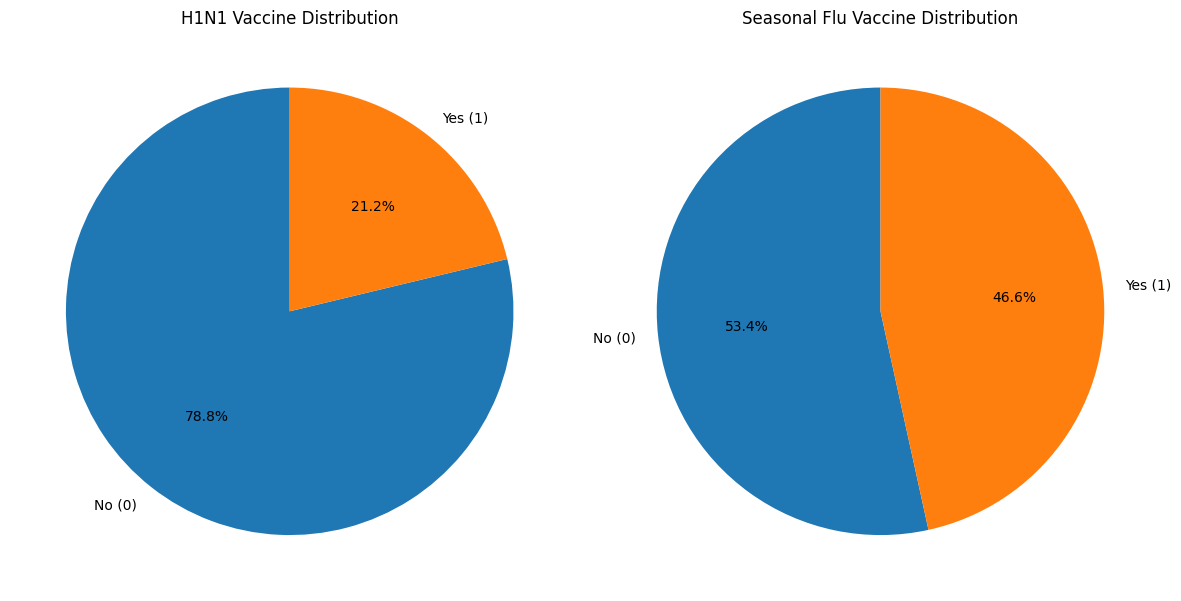

In [29]:
import matplotlib.pyplot as plt

# To compare vaccination distribution
h1n1_counts = train_df['h1n1_vaccine'].value_counts()
seasonal_counts = train_df['seasonal_vaccine'].value_counts()

labels = ['No (0)', 'Yes (1)']

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# H1N1 pie chart
axes[0].pie(
    h1n1_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('H1N1 Vaccine Distribution')

# Seasonal flu pie chart
axes[1].pie(
    seasonal_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Seasonal Flu Vaccine Distribution')

plt.tight_layout()

# Save for README
plt.savefig("images/vaccine_distribution_piecharts.png", dpi=300, bbox_inches="tight")

plt.show()

Interpretation:

Seasonal flu vaccination is more routine while H1N1 may be perceived as less familiar & less trusted

5.2 To assess the relationship between education factors and vaccine uptake.

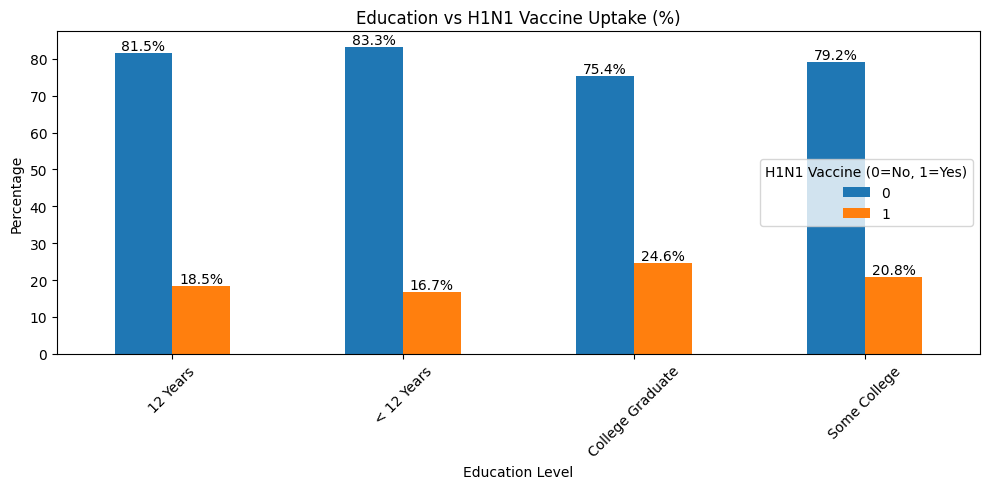

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create percentage table
edu_vax = pd.crosstab(
    train_df['education'],
    train_df['h1n1_vaccine'],
    normalize='index'
) * 100

# Plot grouped bar chart
ax = edu_vax.plot(kind='bar', figsize=(10, 5))

plt.title('Education vs H1N1 Vaccine Uptake (%)')
plt.ylabel('Percentage')
plt.xlabel('Education Level')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xticks(rotation=45)
plt.legend(title='H1N1 Vaccine (0=No, 1=Yes)')
plt.tight_layout()

# Save image
plt.savefig("images/education_vaccine_uptake.png", dpi=300, bbox_inches="tight")

plt.show()

Insight 

Higher education levels show increased vaccination uptake, suggesting that awareness and knowledge influence vaccine acceptance.

5.3 To assess the effect of perceived vaccine effectiveness on vaccination uptake

In [30]:
train_df_clean = train_df.dropna(subset=[
    'opinion_h1n1_vacc_effective',
    'opinion_seas_vacc_effective',
    'h1n1_vaccine',
    'seasonal_vaccine'
])

In [31]:
h1n1_eff_group = train_df_clean.groupby(
    'opinion_h1n1_vacc_effective'
)['h1n1_vaccine'].mean()

seasonal_eff_group = train_df_clean.groupby(
    'opinion_seas_vacc_effective'
)['seasonal_vaccine'].mean()

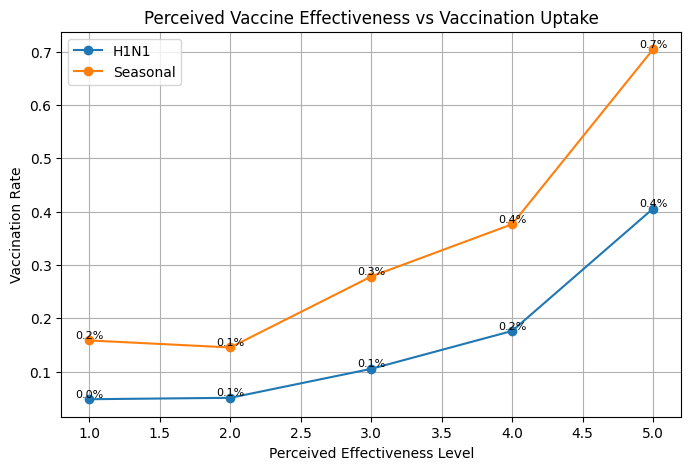

In [33]:
import os
import matplotlib.pyplot as plt

# Ensure folder exists (safe even if already created)
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,5))

# Plot lines with markers
plt.plot(h1n1_eff_group.index, h1n1_eff_group.values,
         marker='o', label='H1N1')

plt.plot(seasonal_eff_group.index, seasonal_eff_group.values,
         marker='o', label='Seasonal')

# ----------------------------
# Add data labels (X, Y points)
# ----------------------------
for x, y in zip(h1n1_eff_group.index, h1n1_eff_group.values):
    plt.text(x, y, f"{y:.1f}%", ha='center', va='bottom', fontsize=8)

for x, y in zip(seasonal_eff_group.index, seasonal_eff_group.values):
    plt.text(x, y, f"{y:.1f}%", ha='center', va='bottom', fontsize=8)

# Titles and labels
plt.title('Perceived Vaccine Effectiveness vs Vaccination Uptake')
plt.xlabel('Perceived Effectiveness Level')
plt.ylabel('Vaccination Rate')
plt.legend()
plt.grid(True)

# Save image
plt.savefig("images/perceived_effectiveness.png", bbox_inches="tight", dpi=300)

plt.show()

Insight 

Low perceived effectiveness is a major barrier to vaccination uptake.

People who believe vaccines are more effective are significantly more likely to get vaccinated.

5.4 To establish effect of perceived disease risk and vaccine effectiveness on H1N1 and seasonal influenza vaccination uptake

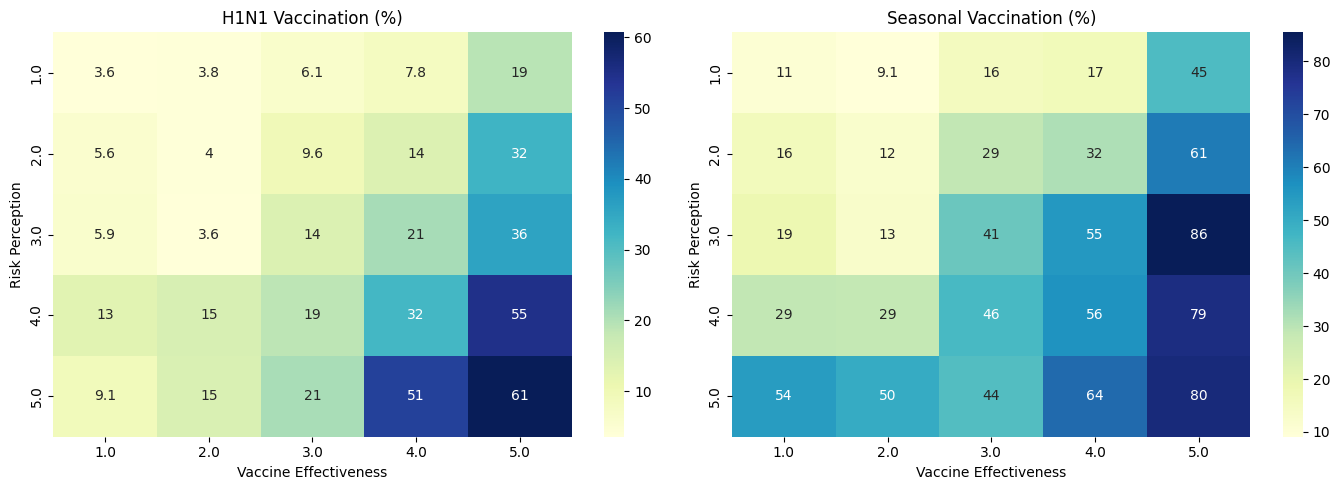

Saved figure to: images/vaccine_heatmaps.png


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


h1n1_heat = pd.crosstab(
    train_df['opinion_h1n1_risk'],
    train_df['opinion_h1n1_vacc_effective'],
    values=train_df['h1n1_vaccine'],
    aggfunc='mean'
) * 100


seas_heat = pd.crosstab(
    train_df['opinion_seas_risk'],
    train_df['opinion_seas_vacc_effective'],
    values=train_df['seasonal_vaccine'],
    aggfunc='mean'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(h1n1_heat, annot=True, cmap='YlGnBu', ax=axes[0])
axes[0].set_title('H1N1 Vaccination (%)')
axes[0].set_xlabel('Vaccine Effectiveness')
axes[0].set_ylabel('Risk Perception')

sns.heatmap(seas_heat, annot=True, cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Seasonal Vaccination (%)')
axes[1].set_xlabel('Vaccine Effectiveness')
axes[1].set_ylabel('Risk Perception')

plt.tight_layout()

output_path = "images/vaccine_heatmaps.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {output_path}")

Insight

Across both H1N1 and seasonal flu, as risk perception and vaccine effectiveness vaccination rates increase.

## 6. modelling

In [35]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

Train model

In [36]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Prediction

In [37]:
y_pred = model.predict(X_val)
y_pred

array([[0, 0],
       [1, 1],
       [0, 0],
       ...,
       [0, 0],
       [0, 1],
       [0, 1]], shape=(5342, 2))

## 7. Evaluate of random forest model

In [38]:
accuracy_h1n1 = accuracy_score(y_val['h1n1_vaccine'], y_pred[:, 0])
accuracy_seasonal = accuracy_score(y_val['seasonal_vaccine'], y_pred[:, 1])

print("H1N1 Accuracy:", accuracy_h1n1)
print("Seasonal Accuracy:", accuracy_seasonal)

H1N1 Accuracy: 0.8335829277424186
Seasonal Accuracy: 0.7768625982777986


In [39]:
print("H1N1 Report:")
print(classification_report(y_val['h1n1_vaccine'], y_pred[:, 0]))

print("Seasonal Report:")
print(classification_report(y_val['seasonal_vaccine'], y_pred[:, 1]))

H1N1 Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      4207
           1       0.73      0.34      0.47      1135

    accuracy                           0.83      5342
   macro avg       0.79      0.66      0.68      5342
weighted avg       0.82      0.83      0.81      5342

Seasonal Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      2854
           1       0.77      0.75      0.76      2488

    accuracy                           0.78      5342
   macro avg       0.78      0.77      0.78      5342
weighted avg       0.78      0.78      0.78      5342



Interpretation 

H1N1 Model
This model is extremely biased toward predicting “not vaccinated” (class 0).

Almost perfectly identifies non-vaccinated individuals but fails to detect vaccinated individuals

Recall (class 1) = 0.34, The model misses 66% of vaccinated people

Most people who actually took the vaccine are being ignored by the model

Seasonal Model
This is a well-balanced and reliable model.
The model is consistently good at identifying both vaccinated and non-vaccinated individuals

Observation 

H1N1: Accuracy: 0.83 (looks good but misleading)

Recall for class 1: 0.34 (very low)- missing most people who actually took the vaccine

Seasonal:- Balanced performance which indicate no major issue

Conclusion 

model is biased toward predicting 0 (no vaccine) for H1N1 which is likely caused by class imbalance

In [40]:
print(confusion_matrix(y_val['h1n1_vaccine'], y_pred[:, 0]))


[[4062  145]
 [ 744  391]]


In [41]:
print(confusion_matrix(y_val['seasonal_vaccine'], y_pred[:, 1]))

[[2295  559]
 [ 633 1855]]


Class imbalance for h1n1_vaccine

Class 0: 4207
Class 1: 1135

## Class imbalance and way out for random forest

In [42]:
# Introcduction of weight 

RandomForestClassifier(random_state=42, class_weight='balanced')

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
# Rebuilding and training

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [44]:
# Prediction after rebulind model 
y_pred = model.predict(X_val)

In [45]:
accuracy_h1n1 = accuracy_score(y_val['h1n1_vaccine'], y_pred[:, 0])
accuracy_seasonal = accuracy_score(y_val['seasonal_vaccine'], y_pred[:, 1])

print("H1N1 Accuracy:", accuracy_h1n1)
print("Seasonal Accuracy:", accuracy_seasonal)

print("H1N1 Report:")
print(classification_report(y_val['h1n1_vaccine'], y_pred[:, 0]))

print("Seasonal Report:")
print(classification_report(y_val['seasonal_vaccine'], y_pred[:, 1]))

H1N1 Accuracy: 0.8318981654810932
Seasonal Accuracy: 0.7753650318232872
H1N1 Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4207
           1       0.72      0.35      0.47      1135

    accuracy                           0.83      5342
   macro avg       0.78      0.65      0.68      5342
weighted avg       0.82      0.83      0.81      5342

Seasonal Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      2854
           1       0.77      0.74      0.75      2488

    accuracy                           0.78      5342
   macro avg       0.77      0.77      0.77      5342
weighted avg       0.78      0.78      0.77      5342



Interpretation 

H1N1 Model, This model is very conservative—it rarely predicts “vaccinated”.

Critical issue:
Recall (class 1) = 0.35
→ It misses 65% of vaccinated people
Even worse than your improved model earlier (which had recall = 0.63)

accuracy looks high,Dataset is imbalanced (many more class 0)
Model predicts mostly 0s, boosting accuracy

Accuracy = 0.83 is misleading here

Tuning of Random forest

In [46]:
# Getting predicition probability

y_proba = model.predict_proba(X_val)
h1n1_probs = y_proba[0][:, 1]   # model have multiple output h1n1 & seasonal vaccine

In [47]:
y_pred_h1n1 = (h1n1_probs > 0.3).astype(int)

In [48]:
print(classification_report(y_val['h1n1_vaccine'], y_pred_h1n1))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4207
           1       0.56      0.63      0.59      1135

    accuracy                           0.82      5342
   macro avg       0.73      0.75      0.74      5342
weighted avg       0.82      0.82      0.82      5342



| Metric              | Before   | Now        |
| ------------------- | -------- | ---------- |
| Recall (class 1)    | 0.35     | 0.63       |
| Precision (class 1) | 0.72     | 0.56       |
| F1-score            | 0.47     | 0.59       |


In [49]:
# for best threshold
best_t = 0
best_f1 = 0

for t in np.arange(0.1, 0.6, 0.05):
    preds = (h1n1_probs > t).astype(int)
    f1 = f1_score(y_val['h1n1_vaccine'], preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.30000000000000004
Best F1: 0.5923777961888981


Tuned threshold (0.3)

In [50]:
BEST_THRESHOLD = 0.3
final_h1n1_pred = (h1n1_probs > BEST_THRESHOLD).astype(int)

Evaluating final H1N1 & seasonal vaccination 

In [51]:
print("Final H1N1 Report:")
print(classification_report(y_val['h1n1_vaccine'], final_h1n1_pred))

print("Final H1N1 Accuracy:", accuracy_score(y_val['h1n1_vaccine'], final_h1n1_pred))

#For now, keep default threshold 
seasonal_probs = y_proba[1][:, 1]
final_seasonal_pred = (seasonal_probs > 0.5).astype(int)

# Evaluate seasonal model
print("Final Seasonal Report:")
print(classification_report(y_val['seasonal_vaccine'], final_seasonal_pred))

Final H1N1 Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4207
           1       0.56      0.63      0.59      1135

    accuracy                           0.82      5342
   macro avg       0.73      0.75      0.74      5342
weighted avg       0.82      0.82      0.82      5342

Final H1N1 Accuracy: 0.8157993260950954
Final Seasonal Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      2854
           1       0.77      0.74      0.75      2488

    accuracy                           0.78      5342
   macro avg       0.77      0.77      0.77      5342
weighted avg       0.78      0.78      0.77      5342



Interpretation 

This is a well-balanced and significantly improved model

model can now meaningfully detect vaccine uptake, while still maintaining strong overall accuracy.

In [52]:
final_predictions = np.column_stack((final_h1n1_pred, final_seasonal_pred))
final_predictions

array([[0, 0],
       [1, 1],
       [0, 0],
       ...,
       [0, 0],
       [0, 1],
       [1, 0]], shape=(5342, 2))

Introduction of Decision Tree model

Building Decision tree model

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

In [54]:
# Training on train data

dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Getting prediction

In [55]:
dt_pred = dt_model.predict(X_val)

dt_h1n1_pred = dt_pred[:, 0]
dt_seasonal_pred = dt_pred[:, 1]

Evaluate Decision Tree (baseline comparison)

In [56]:
print("Decision Tree - H1N1:")
print(classification_report(y_val['h1n1_vaccine'], dt_h1n1_pred))

print("\nDecision Tree - Seasonal:")
print(classification_report(y_val['seasonal_vaccine'], dt_seasonal_pred))

Decision Tree - H1N1:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4207
           1       0.44      0.45      0.45      1135

    accuracy                           0.76      5342
   macro avg       0.64      0.65      0.65      5342
weighted avg       0.76      0.76      0.76      5342


Decision Tree - Seasonal:
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      2854
           1       0.66      0.66      0.66      2488

    accuracy                           0.68      5342
   macro avg       0.68      0.68      0.68      5342
weighted avg       0.68      0.68      0.68      5342



Decision Tree – H1N1
This model is strong on the majority class (0) but weak on the minority class (1)

Decision Tree – Seasonal
This model is balanced but not very strong.
Performance is only moderate (~0.66–0.70 across metrics)

#### To Improve #####

In [57]:
dt_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

dt_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Making prediction probability for Decision tree

In [58]:
dt_proba = dt_balanced.predict_proba(X_val)

dt_h1n1_probs = dt_proba[0][:, 1]
dt_seasonal_probs = dt_proba[1][:, 1]

sanity check the probability

In [59]:
print("Unique H1N1 probs:", np.unique(dt_h1n1_probs)[:10])

Unique H1N1 probs: [0. 1.]


Apply initial thresholds

In [60]:
# start with a lower threshold for the imbalanced target
dt_h1n1_pred = (dt_h1n1_probs > 0.3).astype(int)

# seasonal is fairly balanced (balanced → keep 0.5)
dt_seasonal_pred = (dt_seasonal_probs > 0.5).astype(int)

Evaluate

In [61]:
print("Decision Tree - H1N1:")
print(classification_report(y_val['h1n1_vaccine'], dt_h1n1_pred))

print("\nDecision Tree - Seasonal:")
print(classification_report(y_val['seasonal_vaccine'], dt_seasonal_pred))

Decision Tree - H1N1:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4207
           1       0.43      0.45      0.44      1135

    accuracy                           0.76      5342
   macro avg       0.64      0.65      0.64      5342
weighted avg       0.76      0.76      0.76      5342


Decision Tree - Seasonal:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      2854
           1       0.67      0.65      0.66      2488

    accuracy                           0.69      5342
   macro avg       0.69      0.69      0.69      5342
weighted avg       0.69      0.69      0.69      5342



Decision Tree – H1N1

This model is fairly balanced for class 0, but weak for class 1   
The model is not reliable for detecting vaccine uptake

Decision Tree – Seasonal

This is a well-balanced but weaker model overall.
The model is stable but not highly predictive

To Improves minority class learning (H1N1 = 1) & increase recall immediately

In [62]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'   # CRITICAL
    ))
])

In [63]:
param_grid = {
    'classifier__max_depth': [3, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__ccp_alpha': [0.0, 0.001, 0.01]
}

In [64]:
grid = GridSearchCV(
    dt_model,
    param_grid,
    cv=3,
    scoring='f1',   # focus on balance
    n_jobs=-1
)

grid.fit(X_train, y_train['h1n1_vaccine'])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__ccp_alpha': [0.0, 0.001, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

get best model

In [65]:
best_dt = grid.best_estimator_  #best Decision Tree from GridSearch
dt_probs = best_dt.predict_proba(X_val)[:, 1] # probability of class 1 (H1N1 = vaccinated)

In [66]:
# Convert probabilities to predictions with base line threshold 

dt_pred_05 = (dt_probs > 0.5).astype(int)

Evaluate baseline tuned tree

In [67]:
print("Decision Tree (Tuned) - H1N1 @ 0.5 threshold:")
print(classification_report(y_val['h1n1_vaccine'], dt_pred_05))

Decision Tree (Tuned) - H1N1 @ 0.5 threshold:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      4207
           1       0.45      0.73      0.56      1135

    accuracy                           0.76      5342
   macro avg       0.68      0.75      0.69      5342
weighted avg       0.82      0.76      0.77      5342



The model now correctly identifies 73% of vaccinated individuals

Tuning Threashold 

In [68]:
best_t = 0
best_f1 = 0

for t in np.arange(0.1, 0.6, 0.05):
    preds = (dt_probs > t).astype(int)
    f1 = f1_score(y_val['h1n1_vaccine'], preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)

Best threshold: 0.5500000000000002


In [69]:
# Evaluation 

final_pred = (dt_probs > best_t).astype(int)

print(classification_report(y_val['h1n1_vaccine'], final_pred))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      4207
           1       0.55      0.63      0.59      1135

    accuracy                           0.81      5342
   macro avg       0.72      0.75      0.73      5342
weighted avg       0.82      0.81      0.82      5342



In [70]:
final_predictions = np.column_stack((final_h1n1_pred, final_seasonal_pred))
final_predictions

array([[0, 0],
       [1, 1],
       [0, 0],
       ...,
       [0, 0],
       [0, 1],
       [1, 0]], shape=(5342, 2))

Comparison Tuned Classification Model (Random Forest

| Metric            | Classification Model | Decision Tree |
|------------------|----------------------|---------------|
| H1N1 Recall      |    0.63              |    0.63         |
| H1N1 F1          |    0.59              |    0.59         |
| Seasonal F1      |    0.75              |    0.66         |
| Stability        |   High               |     Lower       |
| Generalization   |   Better             |     Weak        |

Introduction of Logistic Regression to create new pipepline


In [71]:

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_models = {
    "h1n1": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    
    "seasonal": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ])
}

# Train models
log_models["h1n1"].fit(X_train, y_train['h1n1_vaccine'])
log_models["seasonal"].fit(X_train, y_train['seasonal_vaccine'])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [73]:
# Prediction 
h1n1_pred = log_models["h1n1"].predict(X_val)
seasonal_pred = log_models["seasonal"].predict(X_val)

In [74]:
# Evaluation 

from sklearn.metrics import classification_report, accuracy_score

print("Logistic Regression - H1N1")
print(classification_report(y_val['h1n1_vaccine'], h1n1_pred))
print("Accuracy:", accuracy_score(y_val['h1n1_vaccine'], h1n1_pred))

print("Logistic Regression - Seasonal")
print(classification_report(y_val['seasonal_vaccine'], seasonal_pred))
print("Accuracy:", accuracy_score(y_val['seasonal_vaccine'], seasonal_pred))

Logistic Regression - H1N1
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4207
           1       0.69      0.44      0.54      1135

    accuracy                           0.84      5342
   macro avg       0.78      0.70      0.72      5342
weighted avg       0.83      0.84      0.83      5342

Accuracy: 0.8395731935604642
Logistic Regression - Seasonal
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2854
           1       0.78      0.75      0.76      2488

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342

Accuracy: 0.7821040808685885


Observation 

H1N1 model issue: Class 1 recall = 0.44 is too low, Meaning: model is missing many vaccinated people which is causedclass imbalance
 
Seasonal model is balanced performance 

Class imbalance handling

In [75]:
#start with Ridge + class balancing
log_h1n1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        solver='lbfgs',
        random_state=42
    ))
])

In [76]:
# multiple regularization types (Grid Search)
param_grid = [
    {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs']
    },
    {
        'classifier__penalty': ['l1'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear']
    },
    {
        'classifier__penalty': ['elasticnet'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__l1_ratio': [0.2, 0.5, 0.8],
        'classifier__solver': ['saga']
    }
]

In [77]:
# GridSearchCV

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    log_h1n1,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train['h1n1_vaccine'])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}, {'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1'], 'classifier__solver': ['liblinear']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosit

In [78]:
# Getting best  model
best_model = grid.best_estimator_

print(grid.best_params_)

{'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


In [79]:
# Evaluation

pred = best_model.predict(X_val)

print(classification_report(y_val['h1n1_vaccine'], pred))


              precision    recall  f1-score   support

           0       0.92      0.79      0.85      4207
           1       0.49      0.73      0.59      1135

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.72      5342
weighted avg       0.83      0.78      0.80      5342



Intrepretation 

The model is good at finding vaccinated people,accuracy of 78%, but not very reliable when it says someone will be vaccinated class 1

For easy visualization of metrics,comparison of model side by side

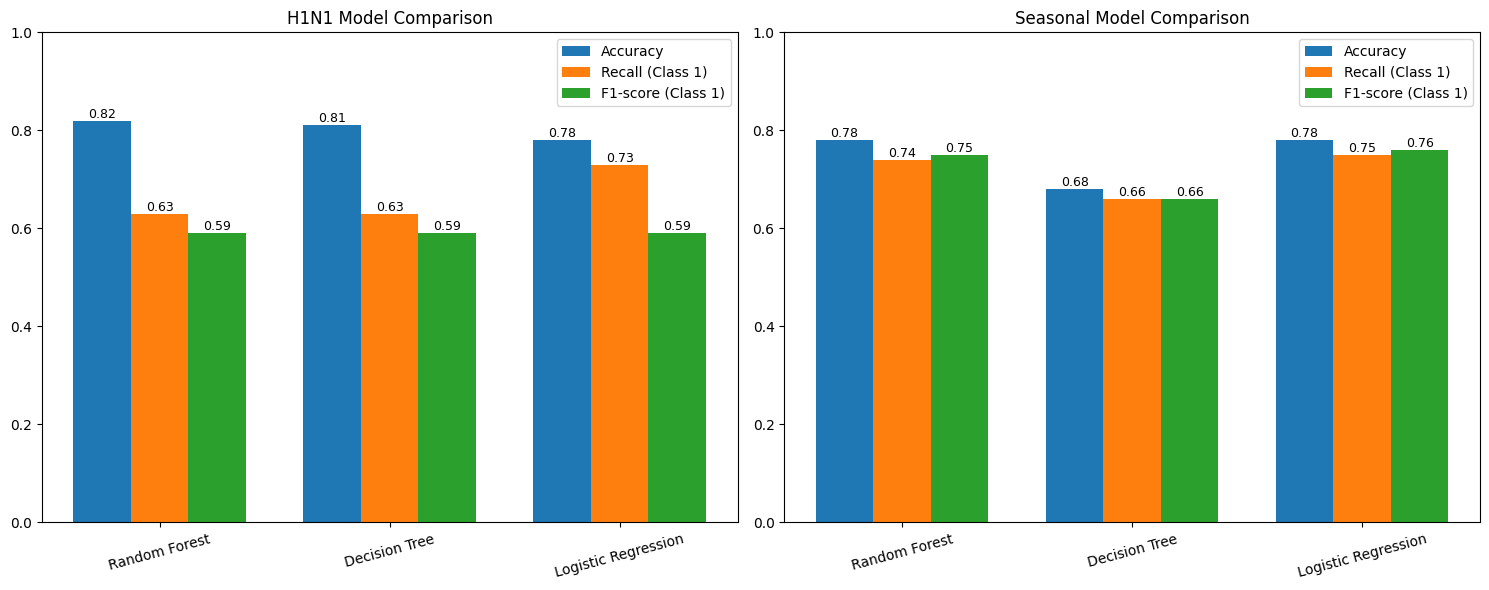

In [84]:

models = ['Random Forest', 'Decision Tree', 'Logistic Regression']

h1n1_accuracy = [0.82, 0.81, 0.78]
h1n1_recall = [0.63, 0.63, 0.73]
h1n1_f1 = [0.59, 0.59, 0.59]

seasonal_accuracy = [0.78, 0.68, 0.78]
seasonal_recall = [0.74, 0.66, 0.75]
seasonal_f1 = [0.75, 0.66, 0.76]

x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )


b1 = axes[0].bar(x - width, h1n1_accuracy, width, label='Accuracy')
b2 = axes[0].bar(x, h1n1_recall, width, label='Recall (Class 1)')
b3 = axes[0].bar(x + width, h1n1_f1, width, label='F1-score (Class 1)')

axes[0].set_title('H1N1 Model Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].legend()

add_labels(axes[0], b1)
add_labels(axes[0], b2)
add_labels(axes[0], b3)


b4 = axes[1].bar(x - width, seasonal_accuracy, width, label='Accuracy')
b5 = axes[1].bar(x, seasonal_recall, width, label='Recall (Class 1)')
b6 = axes[1].bar(x + width, seasonal_f1, width, label='F1-score (Class 1)')

axes[1].set_title('Seasonal Model Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylim(0, 1)
axes[1].legend()

add_labels(axes[1], b4)
add_labels(axes[1], b5)
add_labels(axes[1], b6)

plt.tight_layout()


plt.savefig("images/model_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

In [85]:
import os

print(os.path.exists("images/model_comparison.png"))

True


## Final model to be deployed for prediction 

final_predictions = np.column_stack((final_h1n1_pred, final_seasonal_pred))
final_predictions

## subjecting test data to same pipeline

In [ ]:
# for preprocessing, model prediction and output inline with training features
y_proba_test = model.predict_proba(X_test)

In [ ]:
# Extract probabilities for each target
h1n1_probs_test = y_proba_test[0][:, 1]
seasonal_probs_test = y_proba_test[1][:, 1]

In [ ]:
# Apply your tuned thresholds
BEST_H1N1_THRESHOLD = 0.3
BEST_SEASONAL_THRESHOLD = 0.5   # you kept default

In [ ]:
# Now convert probabilities → predictions:

final_h1n1_test = (h1n1_probs_test > BEST_H1N1_THRESHOLD).astype(int)
final_seasonal_test = (seasonal_probs_test > BEST_SEASONAL_THRESHOLD).astype(int)

In [ ]:
# Combine predictions
final_predictions = np.column_stack((final_h1n1_test, final_seasonal_test))

creating final output

In [ ]:
submission = pd.DataFrame({
    'respondent_id': test_features['respondent_id'],
    'h1n1_vaccine': final_h1n1_test,
    'seasonal_vaccine': final_seasonal_test
})

# Result

In [ ]:
submission.to_csv("final_submission.csv", index=False)

Sanity check

In [ ]:
print(submission.head())
print(submission.shape)

   respondent_id  h1n1_vaccine  seasonal_vaccine
0          26707             0                 0
1          26708             0                 0
2          26709             1                 1
3          26710             1                 1
4          26711             0                 0
(26708, 3)


In [ ]:
print("H1N1 positive rate:", final_h1n1_test.mean())
print("Seasonal positive rate:", final_seasonal_test.mean())

H1N1 positive rate: 0.23573461135240378
Seasonal positive rate: 0.4483300883630373


## 9. Limitation 

High Missing Data reduces the model’s ability to capture socioeconomic disparities hence May lead to biased predictions

Class Imbalance (Vaccinated vs Non-Vaccinated), Limits the model’s effectiveness in identifying individuals likely to accept vaccines

Self-Reported Data Bias, Many variables are based on personal opinions and reported behaviors.
Susceptible to recall bias and social desirability bias.May not accurately reflect actual behavior.

Data represents a single point in time.Cannot capture changes in behavior, perception, or policy over time. Limits ability to model trends or predict future shifts

misclassification of individuals,may lead to poor targeting of vaccination campaigns,vulnerable may be overlooked these could reduce the effectiveness of public health interventions

## 9. Conclusion

Vaccination uptake for both H1N1 and seasonal influenza remains imbalanced, with a larger proportion of individuals not vaccinated. 

Perceived disease risk and belief in vaccine effectiveness emerged as key determinants of vaccination behavior. 

Individuals who perceive higher risk and trust vaccine efficacy are significantly more likely to be vaccinated.

Education level also plays a role, suggesting that awareness and access to accurate health information influence decision-making.

The predictive models achieved good overall accuracy (82% for H1N1 and 78% for seasonal influenza)

## 10..  Business Recommendation

Risk perception drives vaccination, Emphasize personal risk exposure for example age, occupation

Education affects uptake, Use local languages, Use visual communication (charts, infographics), Community outreach programs

Focus intervention on groups predicted as non-vaccinated but high risk

focusing on personal risk 

Improve trust in vaccines through transparent communication

Awareness campaigns on low education population

Leverage healthcare providers to actively recommend vaccination


## 11. Next steps

Deploy targeted vaccination campaigns for high-risk groups

Integrate model into public health systems to identify hesitant individuals

Use clinics and community outreach for awareness programs